Cargo los datos

In [ ]:
import numpy as np
import pandas as pd
from pylab import plt, mpl
import os
import papermill as pm

# Frecuencia obtenida desde el main
try:
    print(f"Frecuencia recibida desde papermill: {frequency}")
except NameError:
    print(f"No se recibió 'frequency'.")

# Cargar los datos para esta frecuencia de un archivo creado por el main
file_name = f"processed_data_{frequency}_WEMH.csv"
data = pd.read_csv(file_name, index_col='timestamp')
data

,BTCUSDTd
timestamp,
2017-08-17,4285.08
2017-08-18,4108.37
2017-08-19,4139.98
2017-08-20,4086.29
2017-08-21,4016.00


Función para guardar los datos. Hace un archivo por cada frecuencia. Guarda en cada línea el modelo que se ha empleado, el activo, accuracy e in/out-sample.

In [ ]:
def save_results(model, ric, acc, sample, frequency=frequency):
    # Verificar si el archivo ya existe
    file_name = f'accuracy_results_{frequency}_WEMH.csv'

    # Si el archivo existe, leer los datos previos, si no, crear un nuevo DataFrame vacío
    if os.path.exists(file_name):
        df_results = pd.read_csv(file_name)
    else:
        df_results = pd.DataFrame(columns=['Model', 'Asset', 'Accuracy', 'IN/OUT Sample'])

    # Agregar la nueva fila con los resultados
    new_row = pd.DataFrame([[model, ric, acc, sample]], columns=['Model', 'Asset', 'Accuracy', 'IN/OUT Sample'])
    df_results = pd.concat([df_results, new_row], ignore_index=True)

    # Guardar los resultados acumulados
    df_results.to_csv(file_name, index=False) 

Representación de los datos

C:\Users\raque\AppData\Local\Temp\ipykernel_17456\28173761.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


'plt.xticks(rotation=35)\nplt.show()'

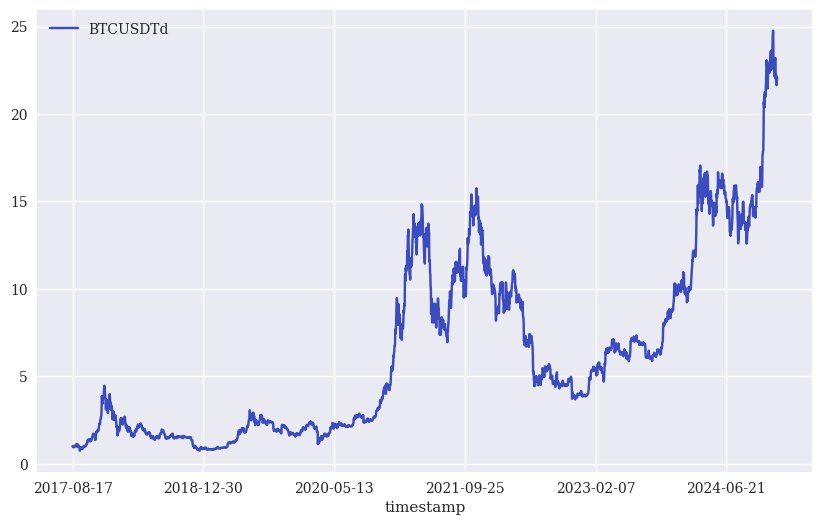

In [ ]:
plt.style.use('seaborn')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
np.set_printoptions(suppress=True, precision=4)
(data / data.iloc[0]).plot(figsize=(10, 6), cmap='coolwarm')
plt.xticks(rotation=35)
plt.show()

Retardamos los datos para crear los lags de cada instante de tiempo

In [8]:
lags = 7

def add_lags(data, ric, lags):
    cols = []
    df = pd.DataFrame(data[ric])
    for lag in range(1, lags + 1):
        col = 'lag_{}'.format(lag)
        df[col] = df[ric].shift(lag)
        cols.append(col)
    df.dropna(inplace=True)
    return df, cols

dfs = {}
for sym in data.columns:
    df, cols = add_lags(data, sym, lags) 
    dfs[sym] = df

dfs[sym].head(7)

,BTCUSDTd,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
timestamp,,,,,,,,
2017-08-24,4316.01,4114.01,4040.00,4016.00,4086.29,4139.98,4108.37,4285.08
2017-08-25,4280.68,4316.01,4114.01,4040.00,4016.00,4086.29,4139.98,4108.37
2017-08-26,4337.44,4280.68,4316.01,4114.01,4040.00,4016.00,4086.29,4139.98
2017-08-27,4310.01,4337.44,4280.68,4316.01,4114.01,4040.00,4016.00,4086.29
2017-08-28,4386.69,4310.01,4337.44,4280.68,4316.01,4114.01,4040.00,4016.00
2017-08-29,4587.48,4386.69,4310.01,4337.44,4280.68,4316.01,4114.01,4040.00
2017-08-30,4555.14,4587.48,4386.69,4310.01,4337.44,4280.68,4316.01,4114.01


In [ ]:
# Modificación del tipo a numérico
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df[sym] = pd.to_numeric(df[sym], errors='coerce')
print(dfs[sym])


            BTCUSDTd     lag_1     lag_2     lag_3     lag_4     lag_5  \
timestamp                                                                
2017-08-24   4316.01   4114.01   4040.00   4016.00   4086.29   4139.98   
2017-08-25   4280.68   4316.01   4114.01   4040.00   4016.00   4086.29   
2017-08-26   4337.44   4280.68   4316.01   4114.01   4040.00   4016.00   
2017-08-27   4310.01   4337.44   4280.68   4316.01   4114.01   4040.00   
2017-08-28   4386.69   4310.01   4337.44   4280.68   4316.01   4114.01   
...              ...       ...       ...       ...       ...       ...   
2024-12-28  95300.00  94299.03  95791.60  99429.60  98663.58  94881.47   
2024-12-29  93738.20  95300.00  94299.03  95791.60  99429.60  98663.58   
2024-12-30  92792.05  93738.20  95300.00  94299.03  95791.60  99429.60   
2024-12-31  93576.00  92792.05  93738.20  95300.00  94299.03  95791.60   
2025-01-01  94591.79  93576.00  92792.05  93738.20  95300.00  94299.03   

               lag_6     lag_7  
time

Se aplica regresión lineal y se muestran los pesos que se le dan a cada lag para hacer la predicción.
Como se puede observar el valor más importante para la predicción es el lag 1, el precio de ayer.

In [10]:
regs = {}
for sym in data.columns:
    df = dfs[sym]
    reg = np.linalg.lstsq(df[cols], df[sym], rcond=-1)[0]
    regs[sym] = reg
rega = np.stack(tuple(regs.values()))
regd = pd.DataFrame(rega, columns=cols, index=data.columns)
regd

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
BTCUSDTd,0.96543,0.050421,-0.017164,0.034137,-0.009257,-0.050694,0.027975


Observamos que los lags están muy relacionados por lo que todos nos aportan más o menos la misma información.

In [11]:
dfs[sym].corr()

,BTCUSDTd,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
BTCUSDTd,1.000000,0.998727,0.997544,0.996317,0.995097,0.993794,0.992433,0.991142
lag_1,0.998727,1.000000,0.998724,0.997537,0.996306,0.995082,0.993775,0.992410
lag_2,0.997544,0.998724,1.000000,0.998720,0.997530,0.996296,0.995068,0.993759
lag_3,0.996317,0.997537,0.998720,1.000000,0.998717,0.997525,0.996287,0.995057
lag_4,0.995097,0.996306,0.997530,0.998717,1.000000,0.998714,0.997518,0.996277
lag_5,0.993794,0.995082,0.996296,0.997525,0.998714,1.000000,0.998710,0.997510
lag_6,0.992433,0.993775,0.995068,0.996287,0.997518,0.998710,1.000000,0.998707
lag_7,0.991142,0.992410,0.993759,0.995057,0.996277,0.997510,0.998707,1.000000


Hacemos un test de Augmented Dickey-Fuller para comprobar la estacionariedad de los datos. 
Como el primer valor es mayor que todos los valores de disintos niveles de confianza no podemos asegurar que la serie sea estacionaria.

In [12]:
from statsmodels.tsa.stattools import adfuller
adfuller(data[sym].dropna())

(-0.43724585465137694,
 0.9036918658714685,
 28,
 2666,
 {'1%': -3.432805216616629,
  '5%': -2.8626247313505173,
  '10%': -2.5673474394742724},
 44966.996435795954)

Ahora calculamos los retornos logaritmicos para poder hacer una aprendizaje con una característica. Intentando que esta sea estacionaria al contrario que los precios tal cual. Normalizamos los retornos y mostramos los retornos retardados.

C:\Users\raque\AppData\Local\Temp\ipykernel_17456\1388203415.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


<Axes: xlabel='timestamp'>

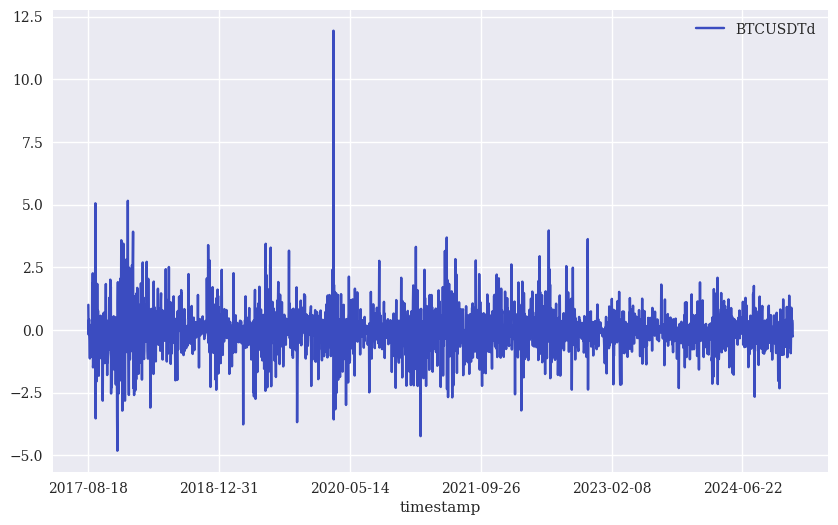

In [13]:
rets = np.log(data / data.shift(1))
rets.dropna(inplace=True)
plt.style.use('seaborn')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
np.set_printoptions(suppress=True, precision=4)
(rets / rets.iloc[0]).plot(figsize=(10, 6), cmap='coolwarm')

In [14]:
dfs = {}
for sym in data:
    df, cols = add_lags(rets, sym, lags)
    mu, std = df[cols].mean(), df[cols].std() 
    df[cols] = (df[cols] - mu) / std
    dfs[sym] = df

dfs[sym].head() 


,BTCUSDTd,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
timestamp,,,,,,,,
2017-08-25,-0.008219,1.239484,0.450170,0.126832,-0.490881,-0.376752,0.172063,-1.147001
2017-08-26,0.013172,-0.248644,1.239349,0.450017,0.126839,-0.490641,-0.376995,0.172102
2017-08-27,-0.006344,0.318274,-0.248732,1.239208,0.450024,0.127070,-0.490887,-0.376927
2017-08-28,0.017635,-0.198943,0.318168,-0.248894,1.239211,0.450250,0.126844,-0.490814
2017-08-29,0.044756,0.436531,-0.199033,0.318013,-0.248885,1.239425,0.450034,0.126885


Los retornos sí son estacionarios.

In [15]:
adfuller(dfs[sym]['lag_1']) 


(-35.84592538657275,
 0.0,
 1,
 2685,
 {'1%': -3.432787825991557,
  '5%': -2.8626170511965543,
  '10%': -2.567343350533518},
 7477.4444825088485)

Y no están correlados.

In [16]:
dfs[sym].corr()

,BTCUSDTd,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
BTCUSDTd,1.000000,-0.050229,0.048224,0.004014,0.011827,0.025486,0.009987,-0.008598
lag_1,-0.050229,1.000000,-0.050024,0.048299,0.003831,0.011626,0.025602,0.009551
lag_2,0.048224,-0.050024,1.000000,-0.049980,0.048248,0.003750,0.011687,0.025480
lag_3,0.004014,0.048299,-0.049980,1.000000,-0.050056,0.048258,0.003708,0.011518
lag_4,0.011827,0.003831,0.048248,-0.050056,1.000000,-0.049943,0.048150,0.003740
lag_5,0.025486,0.011626,0.003750,0.048258,-0.049943,1.000000,-0.049927,0.048402
lag_6,0.009987,0.025602,0.011687,0.003708,0.048150,-0.049927,1.000000,-0.050169
lag_7,-0.008598,0.009551,0.025480,0.011518,0.003740,0.048402,-0.050169,1.000000


Predicciones sin train split, probablemente sobreajustadas.

In [ ]:
from sklearn.metrics import accuracy_score

for sym in data:
    df = dfs[sym]
    reg = np.linalg.lstsq(df[cols], df[sym], rcond=-1)[0]
    pred = np.dot(df[cols], reg)
    acc = accuracy_score(np.sign(df[sym]), np.sign(pred))
    print(f'OLS | {sym:10s} | acc={acc:.4f}')
    save_results('OLS', sym, acc, "IN-SAMPLE")

OLS | BTCUSDTd   | acc=0.5166


In [ ]:
from sklearn.neural_network import MLPRegressor
for sym in data.columns:
    df = dfs[sym]
    model = MLPRegressor(hidden_layer_sizes=[512],
                        random_state=100,
                        max_iter=1000,
                        early_stopping=True,
                        validation_fraction=0.15,
                        shuffle=False)
    model.fit(df[cols], df[sym])
    pred = model.predict(df[cols])
    acc = accuracy_score(np.sign(df[sym]), np.sign(pred))
    print(f'MLP | {sym:10s} | acc={acc:.4f}')
    save_results('MLP', sym, acc, "IN-SAMPLE")

MLP | BTCUSDTd   | acc=0.6003


Ahora entrenamos con unos datos y testeamos con otros (80% entrenamiento, 20% test).

In [ ]:
split = int(len(dfs[sym]) * 0.8)
for sym in data.columns:
    df = dfs[sym]
    train = df.iloc[:split]
    reg = np.linalg.lstsq(train[cols], train[sym], rcond=-1)[0]
    test = df.iloc[split:]
    pred = np.dot(test[cols], reg)
    acc = accuracy_score(np.sign(test[sym]), np.sign(pred))
    print(f'OLS | {sym:10s} | acc={acc:.4f}')
    save_results('OLS', sym, acc, "OUT-SAMPLE")

OLS | BTCUSDTd   | acc=0.5074


In [ ]:
for sym in data.columns:
    df = dfs[sym]
    train = df.iloc[:split]
    model = MLPRegressor(hidden_layer_sizes=[512],
                        random_state=100,
                        max_iter=1000,
                        early_stopping=True,
                        validation_fraction=0.15,
                        shuffle=False)
    model.fit(train[cols], train[sym])
    test = df.iloc[split:]
    pred = model.predict(test[cols])
    acc = accuracy_score(np.sign(test[sym]), np.sign(pred))
    print(f'MLP | {sym:10s} | acc={acc:.4f}')
    save_results('MLP', sym, acc, "OUT-SAMPLE")

MLP | BTCUSDTd   | acc=0.5093


In [ ]:
import tensorflow as tf
from keras.layers import Dense
from keras.models import Sequential

np.random.seed(100)
tf.random.set_seed(100)

def create_model(problem='regression'):
    model = Sequential()
    model.add(Dense(512, input_dim=len(cols),
                    activation='relu'))
    if problem == 'regression':
        model.add(Dense(1, activation='linear'))
        model.compile(loss='mse', optimizer='adam')
    else:
        model.add(Dense(1, activation='sigmoid'))
        model.compile(loss='binary_crossentropy', optimizer='adam')
    return model


for sym in data.columns[:]:
    df = dfs[sym]
    train = df.iloc[:split]
    test = df.iloc[split:]
    model = create_model()
    model.fit(train[cols], train[sym], epochs=25, verbose=False)
    pred = model.predict(test[cols])
    acc = accuracy_score(np.sign(test[sym]), np.sign(pred))
    print(f'DNN | {sym:10s} | acc={acc:.4f}')
    save_results('DNN', sym, acc, "OUT-SAMPLE")

c:\Users\raque\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
DNN | BTCUSDTd   | acc=0.5056


Como podemos ver los resultados no son muy esperanzadores por lo que podemos asumir que los mercados son eficientes al menos en la forma debil. Es decir que no es posible sacar beneficios utilizando unicamente los valores pasados de las acciones. 